<a href="https://colab.research.google.com/github/lukwac123/computer_vision_course/blob/main/10_tensorflow-hub/01_classification_current_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### <a name='a1'></a>Import bibliotek

In [1]:
import sys
import json
import numpy as np
import pandas as pd
import PIL.Image as Image
import tensorflow as tf
import keras
import matplotlib.pyplot as plt

from keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
)

print(f'Python version: {sys.version.split()[0]}')
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

Python version: 3.13.15
TensorFlow version: 2.20.0
Keras version: 3.13.2


### <a name='a2'></a> Załadowanie modelu

In [2]:
IMAGE_SHAPE = (224, 224)

print('[INFO] Ładowanie MobileNetV2...')

classifier = MobileNetV2(
    weights='imagenet',
    include_top=True,
    input_shape=IMAGE_SHAPE + (3,)
)

print('[INFO] Model załadowany.')
print(f'[INFO] Kształt wejścia: {classifier.input_shape}')
print(f'[INFO] Kształt wyjścia: {classifier.output_shape}')

[INFO] Ładowanie MobileNetV2...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Model załadowany.
[INFO] Kształt wejścia: (None, 224, 224, 3)
[INFO] Kształt wyjścia: (None, 1000)


### <a name='a3'></a> Załadowanie etykiet

In [3]:
labels_path = keras.utils.get_file(
    'imagenet_class_index.json',
    'https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json'
)

with open(labels_path, 'r', encoding='utf-8') as file:
    class_index = json.load(file)

imagenet_labels = np.array([
    class_index[str(i)][1]
    for i in range(1000)
])

print(f'[INFO] Liczba etykiet: {len(imagenet_labels)}')
imagenet_labels[:20]

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
[INFO] Liczba etykiet: 1000


array(['tench', 'goldfish', 'great_white_shark', 'tiger_shark',
       'hammerhead', 'electric_ray', 'stingray', 'cock', 'hen', 'ostrich',
       'brambling', 'goldfinch', 'house_finch', 'junco', 'indigo_bunting',
       'robin', 'bulbul', 'jay', 'magpie', 'chickadee'], dtype='<U30')

### <a name='a4'></a> Załadowanie obrazu

In [4]:
from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError('Nie wybrano żadnego obrazu.')

Saving office.jpg to office.jpg


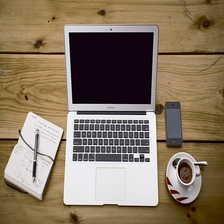

[INFO] Plik: office.jpg
[INFO] Rozmiar po przeskalowaniu: (224, 224)


In [5]:
filename = next(iter(uploaded.keys()))

img = Image.open(filename).convert('RGB')
img = img.resize(IMAGE_SHAPE, Image.Resampling.LANCZOS)

display(img)

print(f'[INFO] Plik: {filename}')
print(f'[INFO] Rozmiar po przeskalowaniu: {img.size}')

### <a name='a5'></a> Predykcja na podstawie modelu

In [6]:
# MobileNetV2 oczekuje danych przygotowanych przez preprocess_input().
# Funkcja przeskalowuje wartości pikseli z [0, 255] do [-1, 1].

img_arr = np.asarray(img, dtype=np.float32)
img_arr = np.expand_dims(img_arr, axis=0)
img_arr = preprocess_input(img_arr)

print(f'[INFO] Kształt danych wejściowych: {img_arr.shape}')

result = classifier.predict(img_arr, verbose=0)

predicted_class = int(np.argmax(result[0]))
predicted_class_name = imagenet_labels[predicted_class]
predicted_probability = float(result[0][predicted_class])

print(f'[INFO] Predykcja: {predicted_class_name}')
print(f'[INFO] Prawdopodobieństwo: {predicted_probability * 100:.2f}%')

top5_idxs = np.argsort(result[0])[::-1][:5]

top5 = pd.DataFrame({
    'class': [imagenet_labels[i] for i in top5_idxs],
    'probability [%]': [
        round(float(result[0][i]) * 100, 2)
        for i in top5_idxs
    ],
})

top5

[INFO] Kształt danych wejściowych: (1, 224, 224, 3)
[INFO] Predykcja: notebook
[INFO] Prawdopodobieństwo: 76.28%


,class,probability [%]
0,notebook,76.28
1,laptop,5.52
2,modem,3.02
3,iPod,2.83
4,mouse,2.00


### <a name='a6'></a> Wyświetlenie predykcji

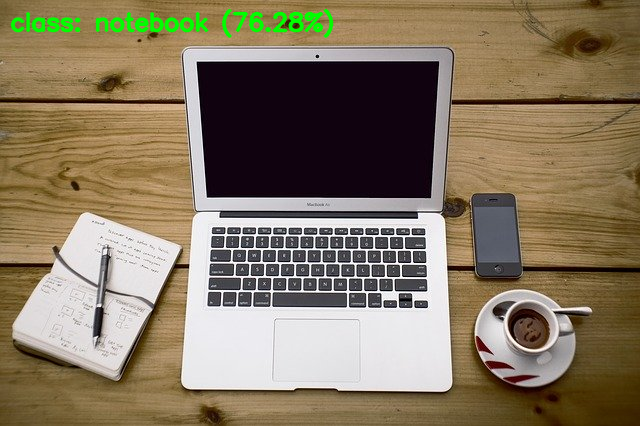

In [7]:
from google.colab.patches import cv2_imshow
import cv2

image_bgr = cv2.imread(filename)

if image_bgr is None:
    raise ValueError(f'Nie można wczytać obrazu: {filename}')

text = (
    f'class: {predicted_class_name} '
    f'({predicted_probability * 100:.2f}%)'
)

cv2.putText(
    img=image_bgr,
    text=text,
    org=(10, 30),
    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
    fontScale=0.8,
    color=(0, 255, 0),
    thickness=2,
    lineType=cv2.LINE_AA
)

cv2_imshow(image_bgr)

### Najważniejsze zmiany względem starej wersji

- usunięto `%tensorflow_version 2.x`,
- usunięto `tensorflow_hub.KerasLayer`,
- model jest ładowany przez `keras.applications.MobileNetV2`,
- zastosowano właściwe dla MobileNetV2 `preprocess_input()`,
- etykiety odpowiadają dokładnie 1000 wyjściom modelu Keras,
- dodano konwersję obrazu do RGB,
- wyświetlane jest prawdopodobieństwo oraz TOP-5 klas.

Ta wersja jest przygotowana do aktualnego środowiska Google Colab z TensorFlow 2.20
i Keras 3.x.